# TwitterFaveGraph

**Два важных решения:**
1. Глобальные ID: `user_index` и `tweet_index` - разные пространства. Строим единый словарь со сквозными ID
2. Сплит без утечки: временной сплит по `time_chunk`; из val/test убираем сущности, которых нет в train

In [37]:
import json
import zipfile
from pathlib import Path

import polars as pl
from huggingface_hub import hf_hub_download

# конфиг
ZIP_NAME = "TwitterFaveGraph.csv.zip"
REL_FAVE = 0
SEED = 42
USER_FRAC = 0.02  # доля юзеров в подвыборке (None = весь граф)

# временной сплит по time_chunk (1..192)
TRAIN_MAX = 180  # train: chunk <= 180
VAL_MAX = 186  # val: 181..186 ; test: 187..192
def find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / ".git").exists() or (p / "notebooks").is_dir():
            return p
    return start

ROOT = find_root(Path.cwd())
RAW = ROOT / "data" / "raw"

# отдельная папка под каждую подвыборку
RUN_TAG = f"frac{USER_FRAC}" if USER_FRAC else "full"
OUT = ROOT / "data" / "processed" / f"favegraph_{RUN_TAG}"
RAW.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)
print("корень:", ROOT)
print("выход :", OUT)

корень: /Users/dzhalilovaaa/twhin-data
выход : /Users/dzhalilovaaa/twhin-data/data/processed/favegraph_frac0.02


## 1. Загрузка данных

In [38]:
zips = list(RAW.glob("*.zip"))

zip_path = zips[0]
print("архив:", zip_path.name)

with zipfile.ZipFile(zip_path) as z:
    z.extractall(RAW)
    
csv_path = list(RAW.glob("*.csv"))[0]
print("готово:", csv_path.name)

архив: TwitterFaveGraph.csv.zip
готово: TwitterFaveGraph.csv


## 2. Беглый осмотр

In [39]:
scan = pl.scan_csv(csv_path)
cols = scan.collect_schema().names()
print("колонки:", cols)
u_col, t_col, c_col = cols[0], cols[1], cols[2]
scan = scan.rename({u_col: "u", t_col: "t", c_col: "chunk"})

# первые строки
display(scan.head(5).collect())
# диапазон time_chunk
print(scan.select(pl.col("chunk").min().alias("min_chunk"), pl.col("chunk").max().alias("max_chunk")).collect())

колонки: ['user_index', 'tweet_index', 'time_chunk']


u,t,chunk
i64,i64,i64
2664563,4656426,134
9109889,3354941,32
10473449,4994572,31
4288842,5859769,133
6032357,6472618,10


shape: (1, 2)
┌───────────┬───────────┐
│ min_chunk ┆ max_chunk │
│ ---       ┆ ---       │
│ i64       ┆ i64       │
╞═══════════╪═══════════╡
│ 1         ┆ 192       │
└───────────┴───────────┘


## 3. Подвыборка по юзерам

Берём долю юзеров и **все их ребра**

In [40]:
if USER_FRAC:
    all_users = scan.select("u").unique().collect(engine="streaming")
    keep = all_users.sample(fraction=USER_FRAC, seed=SEED)
    print(f"юзеров: {all_users.height:,} -> {keep.height:,} ({USER_FRAC:.0%})")
    scan_sub = scan.join(keep.lazy(), on="u", how="inner")
else:
    scan_sub = scan
    print("подвыборка отключена - берем весь граф")

юзеров: 13,130,711 -> 262,614 (2%)


### Проверка

Сверим квантили степени в полном графе и в подвыборке:

In [41]:
if USER_FRAC:
    deg_full = (scan.group_by("u").len().rename({"len": "deg"}).collect(engine="streaming"))
    deg_samp = deg_full.join(keep, on="u", how="inner")

    print("степень юзера — квантили (все vs подвыборка):")
    for q in [0.5, 0.9, 0.99, 1.0]:
        print(f"  q{q:<4}: {deg_full['deg'].quantile(q):8.0f}  vs  {deg_samp['deg'].quantile(q):8.0f}")
    print(f"  mean : {deg_full['deg'].mean():8.2f}  vs  {deg_samp['deg'].mean():8.2f}")

степень юзера — квантили (все vs подвыборка):
  q0.5 :       14  vs        14
  q0.9 :       53  vs        53
  q0.99:       87  vs        87
  q1.0 :      100  vs       100
  mean :    21.62  vs     21.61


Близкие квантили => подвыборка не смещена по активности юзеров

## 4. Дедуп ребер (по минимальному chunk)

Если лайк повторялся в разных чанках — оставляем ранний, чтобы ребро не попало в два сплита:

In [42]:
edges = (scan_sub.group_by("u", "t").agg(pl.col("chunk").min().alias("chunk")).collect(engine="streaming"))
print(f"уникальных ребер: {edges.height:,}")
display(edges.head(3))

уникальных ребер: 5,672,420


u,t,chunk
i64,i64,i64
5688089,3488082,61
12753207,3775889,62
9121078,1974855,180


## 4а. Немного аналитики

Изучаем данные перед тем, как строить эмбеддинги:
- активность по времени
- распределения степеней
- доля однолайковых твитов

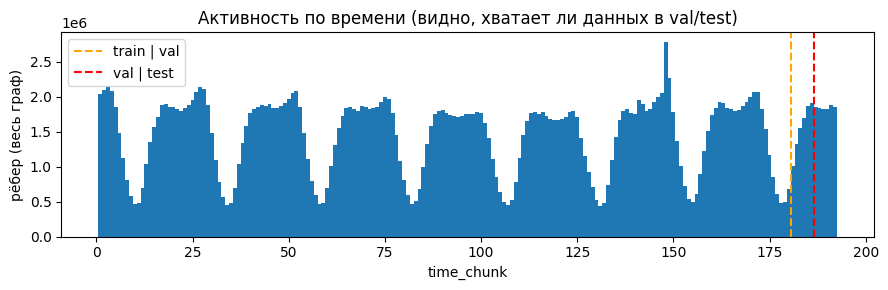

In [43]:
import matplotlib.pyplot as plt

# активность по времени на всем графе
act = scan.group_by("chunk").len().sort("chunk").collect(engine="streaming")
plt.figure(figsize=(9, 3))
plt.bar(act["chunk"].to_list(), act["len"].to_list(), width=1.0)
plt.axvline(TRAIN_MAX + 0.5, color="orange", ls="--", label="train | val")
plt.axvline(VAL_MAX + 0.5, color="red", ls="--", label="val | test")
plt.xlabel("time_chunk"); plt.ylabel("рёбер (весь граф)")
plt.title("Активность по времени (видно, хватает ли данных в val/test)")
plt.legend(); plt.tight_layout(); plt.show()

Видим цикличную активномсть, объем стабилен во времени. Train и test из одного распределения, наши val/test хорошо заполнены => данных для оценки должно хватить. Один разовый всплеск ~chunk 148 - видимо было какое-то событие, на сплит не влияет

user out-degree:  mean=  21.6  median=14  max=100
tweet in-degree:  mean=   3.1  median=1  max=5640
твитов всего: 1,803,009; с единственным лайком: 1,198,446 (66%)


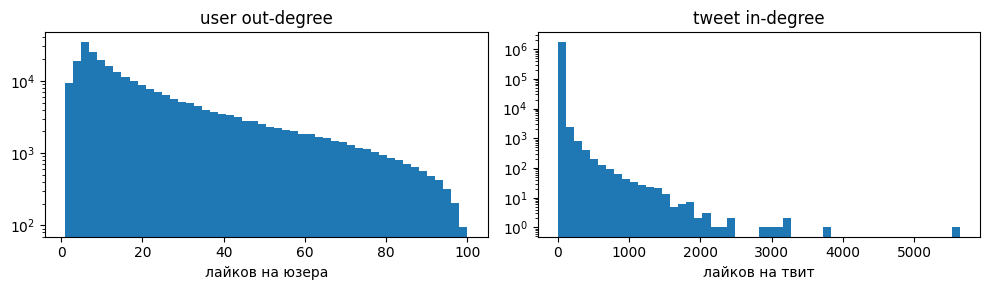

In [44]:
# распределения степеней (на подвыборке)
ud = edges.group_by("u").len()["len"]   # сколько твитов лайкнул юзер
td = edges.group_by("t").len()["len"]   # сколько юзеров лайкнули твит

print(f"user out-degree:  mean={ud.mean():6.1f}  median={ud.median():.0f}  max={ud.max()}")
print(f"tweet in-degree:  mean={td.mean():6.1f}  median={td.median():.0f}  max={td.max()}")
one = (td == 1).sum()
print(f"твитов всего: {td.len():,}; с единственным лайком: {one:,} ({one/td.len():.0%})")

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist(ud.to_list(), bins=50); ax[0].set_yscale("log")
ax[0].set_title("user out-degree"); ax[0].set_xlabel("лайков на юзера")
ax[1].hist(td.to_list(), bins=50); ax[1].set_yscale("log")
ax[1].set_title("tweet in-degree"); ax[1].set_xlabel("лайков на твит")
plt.tight_layout(); plt.show()

Юзеры: плавный спад

Твиты: 66% твитов имеют ровно 1 лайк, но есть вирусные до 5584, граф сильно асимметричен

Главный вывод: популярность твитов распределена по power-law, а значит при частотном негативном сэмплинге вирусные твиты будут доминировать. Этот popularity-bias исправляет logQ-коррекция

## 5. Глобальный словарь сущностей

users → ID `[0..U)`, tweets → ID `[U..U+T)`

In [45]:
users = (edges.select(pl.col("u").alias("orig")).unique().sort("orig").with_row_index("entity_id"))
n_users = users.height

tweets = (edges.select(pl.col("t").alias("orig")).unique().sort("orig").with_row_index("entity_id").with_columns(pl.col("entity_id") + n_users))

print(f"users={n_users:,}  tweets={tweets.height:,}")

entities = pl.concat([
    users.select(pl.col("entity_id").cast(pl.Int64), pl.lit("user").alias("entity_type"), pl.col("orig").cast(pl.Utf8).alias("orig_id")),
    tweets.select(pl.col("entity_id").cast(pl.Int64), pl.lit("tweet").alias("entity_type"), pl.col("orig").cast(pl.Utf8).alias("orig_id")),
])

umap = users.select(pl.col("orig").alias("u"), pl.col("entity_id").cast(pl.Int64).alias("lhs"))
tmap = tweets.select(pl.col("orig").alias("t"), pl.col("entity_id").cast(pl.Int64).alias("rhs"))
display(entities.head(3))

users=262,614  tweets=1,803,009


entity_id,entity_type,orig_id
i64,str,str
0,"""user""","""27"""
1,"""user""","""57"""
2,"""user""","""74"""


## 6. Триплеты + временной сплит

In [46]:
triples = (edges.join(umap, on="u").join(tmap, on="t")
    .with_columns(
        pl.lit(REL_FAVE, dtype=pl.Int32).alias("rel"),
        pl.when(pl.col("chunk") <= TRAIN_MAX).then(pl.lit("train"))
          .when(pl.col("chunk") <= VAL_MAX).then(pl.lit("val"))
          .otherwise(pl.lit("test")).alias("split"))
    .select("lhs", "rel", "rhs", "split"))

display(triples.group_by("split").len().sort("split"))

split,len
str,u32
"""test""",222587
"""train""",5263114
"""val""",186719


## 7. Оставляем в val/test только сущности из train

Иначе у cold-сущности нет эмбеддинга и метрика будет бессмысленна

In [47]:
train = triples.filter(pl.col("split") == "train")
train_ids = pl.concat([train.select(pl.col("lhs").alias("id")), train.select(pl.col("rhs").alias("id"))]).unique()

holdout = triples.filter(pl.col("split") != "train")
# оставляем ребра, где и lhs, и rhs есть в train (semi-join)
holdout_clean = (holdout
    .join(train_ids.select(pl.col("id").alias("lhs")), on="lhs", how="semi")
    .join(train_ids.select(pl.col("id").alias("rhs")), on="rhs", how="semi"))
dropped = holdout.height - holdout_clean.height

triples = pl.concat([train, holdout_clean])
print(f"из val/test удалено {dropped:,} ребер")
display(triples.group_by("split").len().sort("split"))

из val/test удалено 235,886 ребер


split,len
str,u32
"""test""",74247
"""train""",5263114
"""val""",99173


## 8. Запись + отчёт

In [48]:
triples.write_parquet(OUT / "triples.parquet")
entities.write_parquet(OUT / "entities.parquet")
pl.DataFrame({"rel": [REL_FAVE], "rel_name": ["fave"]}).write_parquet(
    OUT / "relations.parquet")

counts = triples.group_by("split").len().sort("split").to_dict(as_series=False)
report = {
    "edges_after_leakfree": triples.height,
    "dropped_coldstart": dropped,
    "n_users": n_users,
    "n_tweets": tweets.height,
    "split_counts": dict(zip(counts["split"], counts["len"])),
    "params": {"user_frac": USER_FRAC, "train_max": TRAIN_MAX,
               "val_max": VAL_MAX, "seed": SEED},
}
(OUT / "split_report.json").write_text(
    json.dumps(report, indent=2, ensure_ascii=False))
print(json.dumps(report, indent=2, ensure_ascii=False))

{
  "edges_after_leakfree": 5436534,
  "dropped_coldstart": 235886,
  "n_users": 262614,
  "n_tweets": 1803009,
  "split_counts": {
    "test": 74247,
    "train": 5263114,
    "val": 99173
  },
  "params": {
    "user_frac": 0.02,
    "train_max": 180,
    "val_max": 186,
    "seed": 42
  }
}


## 9. Проверки

In [49]:
n_ent = entities.height
assert triples["lhs"].max() < n_ent and triples["rhs"].max() < n_ent, "ID выходит за словарь"
assert triples.select(pl.struct("lhs", "rhs")).is_duplicated().sum() == 0, "есть дубликаты рёбер"
ho = triples.filter(pl.col("split") != "train")
assert ho.join(train_ids.select(pl.col("id").alias("lhs")), on="lhs", how="anti").height == 0, "утечка lhs"
assert ho.join(train_ids.select(pl.col("id").alias("rhs")), on="rhs", how="anti").height == 0, "утечка rhs"
print("все проверки пройдены")

все проверки пройдены
